# Hybrid Stacking Sales Forecasting

## Project Goal

This notebook trains a **true hybrid sales forecasting model** on the Walmart Kaggle dataset.

The final model is not just a simple ensemble. It uses **stacking**, where:

1. CatBoost is trained as a base model.
2. LightGBM is trained as a base model.
3. Their predictions are used as new features.
4. A Ridge Regression meta-learner is trained on those predictions.
5. The trained meta-learner produces the final forecast.

At the end, the trained model is saved as:

```text
hybrid_stacking_model.joblib
```

This file can be downloaded from Kaggle and used directly in a Streamlit or Replit app.

## 1. Install and Import Libraries

This section imports all required packages.

Kaggle usually has many libraries pre-installed, but CatBoost and LightGBM may sometimes need installation depending on the environment.

In [2]:
# Uncomment only if Kaggle says a package is missing.
# !pip install catboost lightgbm joblib

import os
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OrdinalEncoder

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)

## 2. Dataset Path Configuration

This notebook is designed for Kaggle.

Add the dataset **Walmart Recruiting - Store Sales Forecasting** to your Kaggle notebook.

Usually, the dataset appears at:

```text
/kaggle/input/walmart-recruiting-store-sales-forecasting/
```

If your path is different, update `DATA_DIR`.

In [3]:
DATA_DIR = Path("/kaggle/input/datasets/gustavoserafim/walmart-recruiting-store-sales-forecasting-gsr")
OUTPUT_DIR = Path("/kaggle/working")
MODEL_PATH = OUTPUT_DIR / "hybrid_stacking_model.joblib"

print("Dataset folder exists:", DATA_DIR.exists())
print("Available files:")
if DATA_DIR.exists():
    for file in DATA_DIR.iterdir():
        print(" -", file.name)

Dataset folder exists: True
Available files:
 - features.csv
 - sampleSubmission.csv
 - submission.csv
 - stores.csv
 - train.csv
 - test.csv


## 3. Load the Walmart Dataset

The dataset has three important files:

- `train.csv.zip`: historical weekly sales
- `features.csv.zip`: external features such as temperature, fuel price, CPI, unemployment, markdowns
- `stores.csv`: store type and store size

We merge them into one training table.

In [6]:
def load_walmart_data(data_dir):
    train = pd.read_csv(data_dir / "train.csv")
    features = pd.read_csv(data_dir / "features.csv")
    stores = pd.read_csv(data_dir / "stores.csv")

    train["Date"] = pd.to_datetime(train["Date"])
    features["Date"] = pd.to_datetime(features["Date"])

    df = train.merge(stores, on="Store", how="left")
    df = df.merge(features, on=["Store", "Date"], how="left")

    if "IsHoliday_x" in df.columns and "IsHoliday_y" in df.columns:
        df["IsHoliday"] = df["IsHoliday_x"].astype(int)
        df = df.drop(columns=["IsHoliday_x", "IsHoliday_y"])
    elif "IsHoliday" in df.columns:
        df["IsHoliday"] = df["IsHoliday"].astype(int)

    return df

df = load_walmart_data(DATA_DIR)

print("Shape:", df.shape)
display(df.head())

Shape: (421570, 16)


,Store,Dept,Date,Weekly_Sales,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,1,2010-02-05,24924.50,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,0
1,1,1,2010-02-12,46039.49,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,1
2,1,1,2010-02-19,41595.55,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,0
3,1,1,2010-02-26,19403.54,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,0
4,1,1,2010-03-05,21827.90,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,0


## 4. Basic EDA

Before training, we quickly inspect the dataset.

This helps us understand:

- number of stores
- number of departments
- sales range
- missing values
- date range

In [7]:
print("Date range:", df["Date"].min(), "to", df["Date"].max())
print("Unique stores:", df["Store"].nunique())
print("Unique departments:", df["Dept"].nunique())
print("Rows:", len(df))

display(df.describe(include="all").T.head(30))

missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].head(20))

Date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00
Unique stores: 45
Unique departments: 81
Rows: 421570


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Store,421570.0,NaN,NaN,NaN,22.200546,1.0,11.0,22.0,33.0,45.0,12.785297
Dept,421570.0,NaN,NaN,NaN,44.260317,1.0,18.0,37.0,74.0,99.0,30.492054
Date,421570,NaN,NaN,NaN,2011-06-18 08:30:31.963375104,2010-02-05 00:00:00,2010-10-08 00:00:00,2011-06-17 00:00:00,2012-02-24 00:00:00,2012-10-26 00:00:00,NaN
Weekly_Sales,421570.0,NaN,NaN,NaN,15981.258123,-4988.94,2079.65,7612.03,20205.8525,693099.36,22711.183519
Type,421570,3,A,215478,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Size,421570.0,NaN,NaN,NaN,136727.915739,34875.0,93638.0,140167.0,202505.0,219622.0,60980.583328
Temperature,421570.0,NaN,NaN,NaN,60.090059,-2.06,46.68,62.09,74.28,100.14,18.447931
Fuel_Price,421570.0,NaN,NaN,NaN,3.361027,2.472,2.933,3.452,3.738,4.468,0.458515
MarkDown1,150681.0,NaN,NaN,NaN,7246.420196,0.27,2240.27,5347.45,9210.9,88646.76,8291.221345
MarkDown2,111248.0,NaN,NaN,NaN,3334.628621,-265.76,41.6,192.0,1926.94,104519.54,9475.357325


MarkDown2    310322
MarkDown4    286603
MarkDown3    284479
MarkDown1    270889
MarkDown5    270138
dtype: int64

## 5. Sales Trend Visualization

This plot shows total weekly sales over time.

It helps us visually identify seasonality, holiday spikes, and yearly sales patterns.

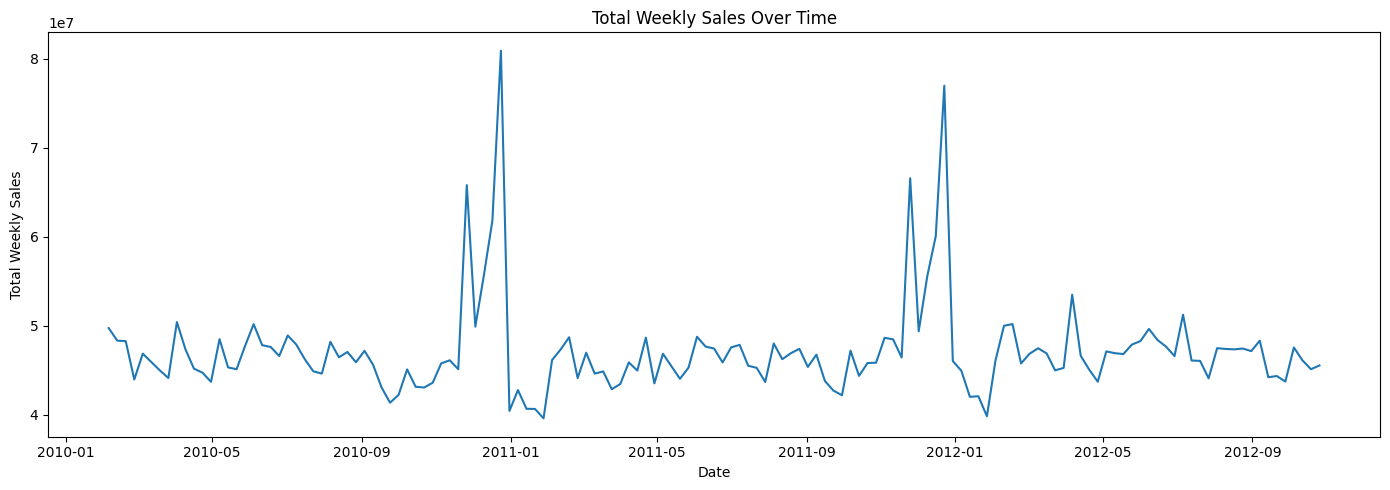

In [8]:
weekly_sales = df.groupby("Date", as_index=False)["Weekly_Sales"].sum()

plt.figure(figsize=(14, 5))
plt.plot(weekly_sales["Date"], weekly_sales["Weekly_Sales"])
plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.tight_layout()
plt.show()

## 6. Feature Engineering

This is one of the most important parts of the project.

We create:

### Calendar features
- Year
- Month
- Week of year
- Month-end flag

### India-aware contextual features
- Indian festival flag
- Monsoon flag

### Leakage-safe sales history features
- previous week sales
- previous 4-week sales
- previous 12-week sales
- rolling mean
- rolling standard deviation

The lag and rolling features are created using only past sales, so they are leakage-safe.

In [9]:
INDIAN_FESTIVALS = {
    "2010-03-01": "Holi",
    "2010-09-10": "Eid",
    "2010-11-05": "Diwali",
    "2010-12-25": "Christmas",
    "2011-03-20": "Holi",
    "2011-08-31": "Eid",
    "2011-10-26": "Diwali",
    "2011-12-25": "Christmas",
    "2012-03-08": "Holi",
    "2012-08-20": "Eid",
    "2012-11-13": "Diwali",
    "2012-12-25": "Christmas",
}

def add_calendar_features(data):
    data = data.copy()
    data["Year"] = data["Date"].dt.year
    data["Month"] = data["Date"].dt.month
    data["WeekOfYear"] = data["Date"].dt.isocalendar().week.astype(int)
    data["IsMonthEnd"] = data["Date"].dt.is_month_end.astype(int)
    return data

def add_indian_context_features(data):
    data = data.copy()
    data["Indian_Festival"] = "None"

    for date_text, festival in INDIAN_FESTIVALS.items():
        festival_week = pd.to_datetime(date_text).to_period("W")
        mask = data["Date"].dt.to_period("W") == festival_week
        data.loc[mask, "Indian_Festival"] = festival

    data["Is_Indian_Festival"] = (data["Indian_Festival"] != "None").astype(int)
    data["Is_Monsoon"] = data["Month"].isin([6, 7, 8, 9]).astype(int)
    return data

def add_lag_and_rolling_features(data):
    data = data.copy()
    data = data.sort_values(["Store", "Dept", "Date"])

    group = data.groupby(["Store", "Dept"], observed=True)["Weekly_Sales"]

    data["Sales_Lag_1"] = group.shift(1)
    data["Sales_Lag_4"] = group.shift(4)
    data["Sales_Lag_12"] = group.shift(12)

    shifted_sales = group.shift(1)

    data["Sales_RollMean_4"] = (
        shifted_sales
        .groupby([data["Store"], data["Dept"]], observed=True)
        .rolling(window=4)
        .mean()
        .reset_index(level=[0, 1], drop=True)
    )

    data["Sales_RollStd_12"] = (
        shifted_sales
        .groupby([data["Store"], data["Dept"]], observed=True)
        .rolling(window=12)
        .std()
        .reset_index(level=[0, 1], drop=True)
    )

    required_lag_cols = [
        "Sales_Lag_1",
        "Sales_Lag_4",
        "Sales_Lag_12",
        "Sales_RollMean_4",
        "Sales_RollStd_12",
    ]

    data = data.dropna(subset=required_lag_cols).copy()
    return data

df_fe = add_calendar_features(df)
df_fe = add_indian_context_features(df_fe)
df_fe = add_lag_and_rolling_features(df_fe)

for col in ["Store", "Dept", "Type", "Indian_Festival"]:
    df_fe[col] = df_fe[col].astype("category")

print("Feature-engineered shape:", df_fe.shape)
display(df_fe.head())

Feature-engineered shape: (382955, 28)


,Store,Dept,Date,Weekly_Sales,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Year,Month,WeekOfYear,IsMonthEnd,Indian_Festival,Is_Indian_Festival,Is_Monsoon,Sales_Lag_1,Sales_Lag_4,Sales_Lag_12,Sales_RollMean_4,Sales_RollStd_12
12,1,1,2010-04-30,16555.11,A,151315,67.41,2.780,NaN,NaN,NaN,NaN,NaN,210.389546,7.808,0,2010,4,17,1,None,0,0,16145.35,57258.43,24924.50,33490.4125,13514.119641
13,1,1,2010-05-07,17413.94,A,151315,72.55,2.835,NaN,NaN,NaN,NaN,NaN,210.339968,7.808,0,2010,5,18,0,None,0,0,16555.11,42960.91,46039.49,23314.5825,13994.005101
14,1,1,2010-05-14,18926.74,A,151315,74.78,2.854,NaN,NaN,NaN,NaN,NaN,210.337426,7.808,0,2010,5,19,0,None,0,0,17413.94,17596.96,41595.55,16927.8400,13258.075480
15,1,1,2010-05-21,14773.04,A,151315,76.44,2.826,NaN,NaN,NaN,NaN,NaN,210.617093,7.808,0,2010,5,20,0,None,0,0,18926.74,16145.35,19403.54,17260.2850,12534.987032
16,1,1,2010-05-28,15580.43,A,151315,80.44,2.759,NaN,NaN,NaN,NaN,NaN,210.896761,7.808,0,2010,5,21,0,None,0,0,14773.04,16555.11,21827.90,16917.2075,12784.712551


## 7. Feature Selection

These are the final input columns used by the models.

The selected features include:

- store identity
- department identity
- store type and size
- date-based seasonal features
- festival and monsoon indicators
- previous sales behavior

In [10]:
TARGET_COL = "Weekly_Sales"

FEATURE_COLS = [
    "Store",
    "Dept",
    "Type",
    "Size",
    "IsHoliday",
    "Year",
    "Month",
    "WeekOfYear",
    "IsMonthEnd",
    "Indian_Festival",
    "Is_Indian_Festival",
    "Is_Monsoon",
    "Sales_Lag_1",
    "Sales_Lag_4",
    "Sales_Lag_12",
    "Sales_RollMean_4",
    "Sales_RollStd_12",
]

CAT_FEATURES = ["Store", "Dept", "Type", "Indian_Festival"]

X = df_fe[FEATURE_COLS]
y = df_fe[TARGET_COL]

print("Features:", FEATURE_COLS)
print("Categorical features:", CAT_FEATURES)

Features: ['Store', 'Dept', 'Type', 'Size', 'IsHoliday', 'Year', 'Month', 'WeekOfYear', 'IsMonthEnd', 'Indian_Festival', 'Is_Indian_Festival', 'Is_Monsoon', 'Sales_Lag_1', 'Sales_Lag_4', 'Sales_Lag_12', 'Sales_RollMean_4', 'Sales_RollStd_12']
Categorical features: ['Store', 'Dept', 'Type', 'Indian_Festival']


## 8. Time-Based Train-Validation Split

For forecasting, a random split is not ideal because it can leak future behavior into training.

So we use a time-based split:

- Train on data before 2012
- Validate on data from 2012 onwards

This simulates real-world forecasting, where the model learns from the past and predicts the future.

In [11]:
TRAIN_CUTOFF_DATE = "2012-01-01"

train_df = df_fe[df_fe["Date"] < TRAIN_CUTOFF_DATE].copy()
val_df = df_fe[df_fe["Date"] >= TRAIN_CUTOFF_DATE].copy()

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]

X_val = val_df[FEATURE_COLS]
y_val = val_df[TARGET_COL]

print("Training rows:", len(X_train))
print("Validation rows:", len(X_val))
print("Train date range:", train_df["Date"].min(), "to", train_df["Date"].max())
print("Validation date range:", val_df["Date"].min(), "to", val_df["Date"].max())

Training rows: 256034
Validation rows: 126921
Train date range: 2010-04-30 00:00:00 to 2011-12-30 00:00:00
Validation date range: 2012-01-06 00:00:00 to 2012-10-26 00:00:00


## 9. Evaluation Function

We evaluate every model using:

- MAE: average absolute error
- MSE: squared error
- RMSE: root mean squared error
- R²: goodness of fit

Higher R² and lower error values indicate better performance.

In [12]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": mse ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }

def show_metrics(name, y_true, y_pred):
    metrics = regression_metrics(y_true, y_pred)
    print(f"\n{name}")
    for key, value in metrics.items():
        print(f"{key}: {value:.6f}")
    return metrics

## 10. Train CatBoost Base Model

CatBoost is used because it handles categorical variables very well.

In this dataset, columns like Store, Dept, Type, and Indian_Festival are categorical identifiers.
CatBoost can learn from them without heavy manual encoding.

In [13]:
cat_model = CatBoostRegressor(
    iterations=350,
    depth=6,
    learning_rate=0.08,
    loss_function="RMSE",
    random_state=RANDOM_STATE,
    verbose=100,
)

cat_model.fit(
    X_train,
    y_train,
    cat_features=CAT_FEATURES,
)

pred_cat_train = cat_model.predict(X_train)
pred_cat_val = cat_model.predict(X_val)

cat_metrics = show_metrics("CatBoost Base Model", y_val, pred_cat_val)

0:	learn: 21555.2428060	total: 186ms	remaining: 1m 4s
100:	learn: 5063.6509266	total: 10.7s	remaining: 26.4s
200:	learn: 4396.5895123	total: 20.9s	remaining: 15.5s
300:	learn: 4102.6518122	total: 31.2s	remaining: 5.08s
349:	learn: 3982.0441069	total: 36.4s	remaining: 0us

CatBoost Base Model
MAE: 1537.009926
MSE: 10805800.973135
RMSE: 3287.217817
R2: 0.977961


## 11. Train LightGBM Base Model

LightGBM is another strong gradient boosting model.

It is fast and effective on large tabular datasets.

Because LightGBM requires numeric inputs, we encode categorical columns using `OrdinalEncoder`.

In [14]:
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_train_lgb = X_train.copy()
X_val_lgb = X_val.copy()

X_train_lgb[CAT_FEATURES] = encoder.fit_transform(X_train_lgb[CAT_FEATURES].astype(str))
X_val_lgb[CAT_FEATURES] = encoder.transform(X_val_lgb[CAT_FEATURES].astype(str))

lgb_model = LGBMRegressor(
    n_estimators=350,
    learning_rate=0.08,
    max_depth=8,
    num_leaves=64,
    random_state=RANDOM_STATE,
)

lgb_model.fit(X_train_lgb, y_train)

pred_lgb_train = lgb_model.predict(X_train_lgb)
pred_lgb_val = lgb_model.predict(X_val_lgb)

lgb_metrics = show_metrics("LightGBM Base Model", y_val, pred_lgb_val)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019483 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1523
[LightGBM] [Info] Number of data points in the train set: 256034, number of used features: 17
[LightGBM] [Info] Start training from score 16311.924744
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

## 12. MAE-Weighted Ensemble Baseline

This section implements the report's weighted voting idea.

The model with lower MAE receives a higher weight.

This is a useful baseline, but the weights are fixed using error values.
The model does not actually learn how to combine predictions.

In [15]:
def mae_weighted_ensemble(y_true, prediction_dict):
    maes = {
        name: mean_absolute_error(y_true, pred)
        for name, pred in prediction_dict.items()
    }

    inverse_errors = {
        name: 1.0 / max(mae, 1e-9)
        for name, mae in maes.items()
    }

    total_inverse_error = sum(inverse_errors.values())

    weights = {
        name: value / total_inverse_error
        for name, value in inverse_errors.items()
    }

    final_pred = np.zeros_like(next(iter(prediction_dict.values())), dtype=float)

    for name, pred in prediction_dict.items():
        final_pred += weights[name] * pred

    return final_pred, weights, maes

mae_ensemble_pred, mae_weights, base_maes = mae_weighted_ensemble(
    y_val,
    {
        "CatBoost": pred_cat_val,
        "LightGBM": pred_lgb_val,
    },
)

mae_ensemble_metrics = show_metrics("MAE-Weighted Ensemble", y_val, mae_ensemble_pred)

print("\nBase model MAEs:")
print(base_maes)

print("\nMAE ensemble weights:")
print(mae_weights)


MAE-Weighted Ensemble
MAE: 1431.535927
MSE: 9605091.315161
RMSE: 3099.208176
R2: 0.980410

Base model MAEs:
{'CatBoost': 1537.009926307997, 'LightGBM': 1414.006560600926}

MAE ensemble weights:
{'CatBoost': 0.47915915308289037, 'LightGBM': 0.5208408469171096}


## 13. Train the True Hybrid Model Using Stacking

This is the main upgrade.

Instead of manually averaging predictions, we train a new model called a **meta-learner**.

### Base learner predictions become meta-features

For each row:

```text
CatBoost prediction + LightGBM prediction -> Ridge meta-learner -> final prediction
```

This is why it is a true trained hybrid model.

In [16]:
def build_meta_features(pred_1, pred_2):
    return np.column_stack([pred_1, pred_2])

X_meta_train = build_meta_features(pred_cat_train, pred_lgb_train)
X_meta_val = build_meta_features(pred_cat_val, pred_lgb_val)

meta_model = Ridge(alpha=1.0)
meta_model.fit(X_meta_train, y_train)

hybrid_pred = meta_model.predict(X_meta_val)

hybrid_metrics = show_metrics("Stacking-Based Hybrid Model", y_val, hybrid_pred)

print("\nMeta-learner coefficients:")
print("CatBoost prediction coefficient:", meta_model.coef_[0])
print("LightGBM prediction coefficient:", meta_model.coef_[1])
print("Intercept:", meta_model.intercept_)


Stacking-Based Hybrid Model
MAE: 1434.744806
MSE: 9962954.289536
RMSE: 3156.414784
R2: 0.979680

Meta-learner coefficients:
CatBoost prediction coefficient: -0.22399143311315617
LightGBM prediction coefficient: 1.2248239586602119
Intercept: -11.996650112292627


## 14. Compare All Models

This comparison is important for the review.

It shows:

1. Individual model performance
2. MAE-weighted ensemble performance
3. Trained hybrid stacking model performance

Your main contribution is the trained hybrid stacking model.

In [17]:
metrics_table = pd.DataFrame([
    {"Model": "CatBoost", **cat_metrics},
    {"Model": "LightGBM", **lgb_metrics},
    {"Model": "MAE-Weighted Ensemble", **mae_ensemble_metrics},
    {"Model": "Stacking Hybrid Model", **hybrid_metrics},
])

metrics_table = metrics_table.sort_values("R2", ascending=False)
display(metrics_table)

metrics_table.to_csv(OUTPUT_DIR / "model_comparison_metrics.csv", index=False)

,Model,MAE,MSE,RMSE,R2
1,LightGBM,1414.006561,9.602004e+06,3098.710023,0.980416
2,MAE-Weighted Ensemble,1431.535927,9.605091e+06,3099.208176,0.980410
3,Stacking Hybrid Model,1434.744806,9.962954e+06,3156.414784,0.979680
0,CatBoost,1537.009926,1.080580e+07,3287.217817,0.977961


## 15. Visualization: Actual vs Predicted

This scatter plot compares the actual sales with the hybrid model predictions.

A good model should have points close to the diagonal line.

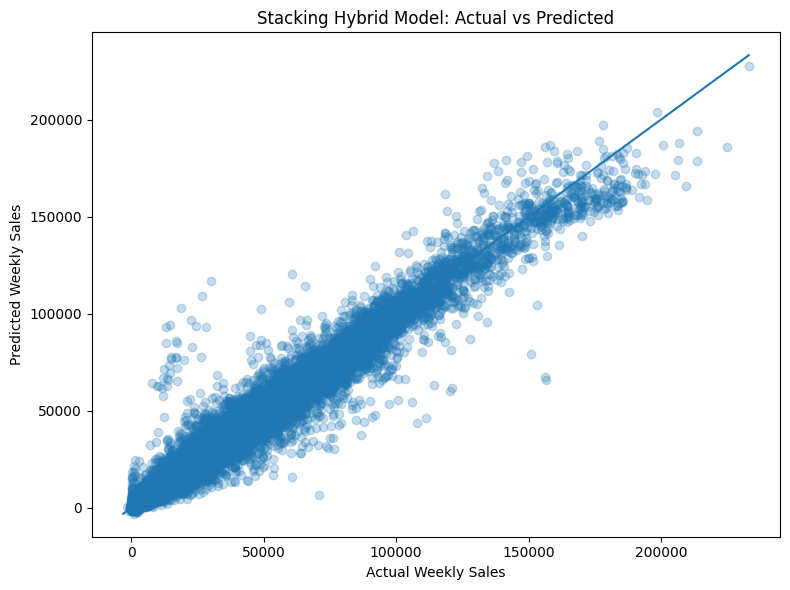

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(y_val, hybrid_pred, alpha=0.25)
plt.xlabel("Actual Weekly Sales")
plt.ylabel("Predicted Weekly Sales")
plt.title("Stacking Hybrid Model: Actual vs Predicted")

mn = min(y_val.min(), hybrid_pred.min())
mx = max(y_val.max(), hybrid_pred.max())
plt.plot([mn, mx], [mn, mx])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "actual_vs_predicted_hybrid.png", dpi=150)
plt.show()

## 16. Visualization: Prediction Error Distribution

This plot shows how prediction errors are distributed.

If most errors are close to zero, the model is performing well.

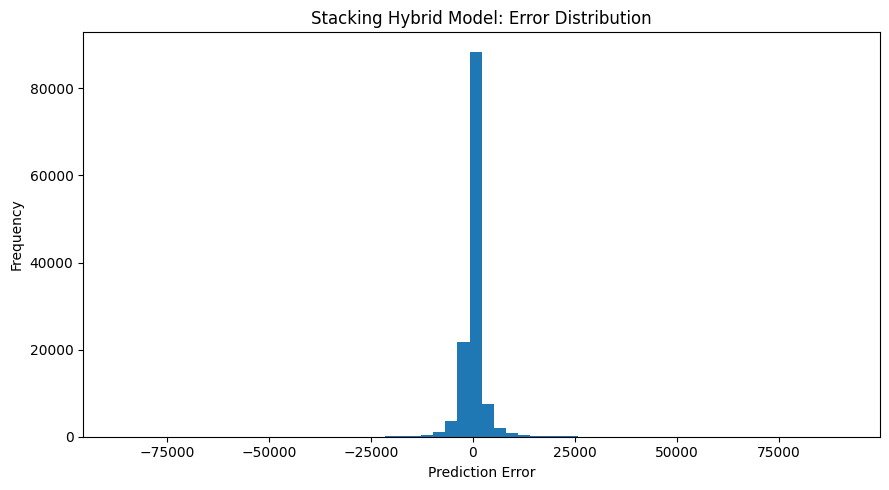

In [19]:
errors = y_val - hybrid_pred

plt.figure(figsize=(9, 5))
plt.hist(errors, bins=60)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Stacking Hybrid Model: Error Distribution")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "error_distribution_hybrid.png", dpi=150)
plt.show()

## 17. Visualization: Sales Over Time

This plot compares total actual weekly sales and predicted weekly sales over time.

It helps demonstrate whether the model captures seasonality and trend changes.

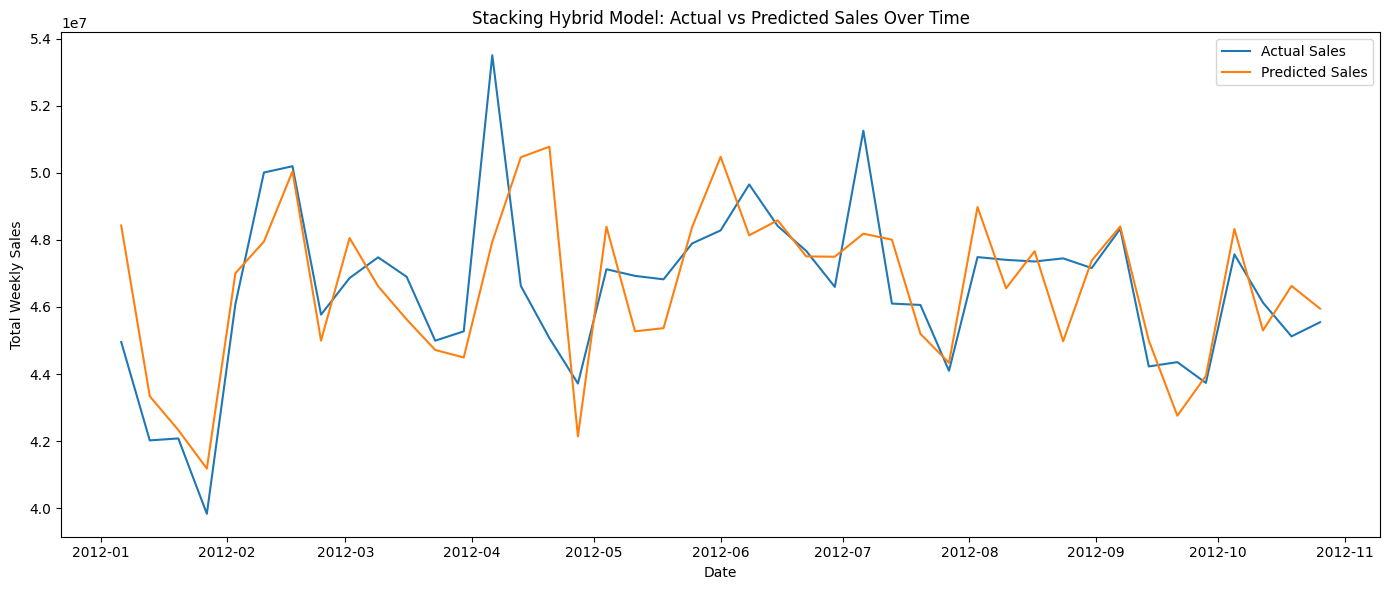

In [20]:
time_plot_df = pd.DataFrame({
    "Date": val_df["Date"].values,
    "Actual": y_val.values,
    "Predicted": hybrid_pred,
})

weekly_plot = time_plot_df.groupby("Date", as_index=False)[["Actual", "Predicted"]].sum()

plt.figure(figsize=(14, 6))
plt.plot(weekly_plot["Date"], weekly_plot["Actual"], label="Actual Sales")
plt.plot(weekly_plot["Date"], weekly_plot["Predicted"], label="Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.title("Stacking Hybrid Model: Actual vs Predicted Sales Over Time")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sales_over_time_hybrid.png", dpi=150)
plt.show()

## 18. Save the Trained Hybrid Model

This is the most important output for deployment.

We save one artifact containing:

- CatBoost model
- LightGBM model
- categorical encoder for LightGBM
- Ridge meta-learner
- feature column names
- categorical column names
- model metrics
- ensemble weights

Download this file from Kaggle output and place it inside your Streamlit app's `models/` folder.

In [21]:
artifact = {
    "catboost_model": cat_model,
    "lightgbm_model": lgb_model,
    "lightgbm_encoder": encoder,
    "meta_model": meta_model,
    "feature_cols": FEATURE_COLS,
    "cat_features": CAT_FEATURES,
    "mae_ensemble_weights": mae_weights,
    "base_model_maes": base_maes,
    "metrics": {
        "CatBoost": cat_metrics,
        "LightGBM": lgb_metrics,
        "MAE_Weighted_Ensemble": mae_ensemble_metrics,
        "Stacking_Hybrid_Model": hybrid_metrics,
    },
    "meta_coefficients": {
        "CatBoost_prediction_coefficient": float(meta_model.coef_[0]),
        "LightGBM_prediction_coefficient": float(meta_model.coef_[1]),
        "Intercept": float(meta_model.intercept_),
    },
}

joblib.dump(artifact, MODEL_PATH)

with open(OUTPUT_DIR / "metrics.json", "w") as f:
    json.dump(artifact["metrics"], f, indent=2)

with open(OUTPUT_DIR / "meta_coefficients.json", "w") as f:
    json.dump(artifact["meta_coefficients"], f, indent=2)

print("Saved model to:", MODEL_PATH)
print("Saved metrics to:", OUTPUT_DIR / "metrics.json")
print("Saved meta coefficients to:", OUTPUT_DIR / "meta_coefficients.json")

Saved model to: /kaggle/working/hybrid_stacking_model.joblib
Saved metrics to: /kaggle/working/metrics.json
Saved meta coefficients to: /kaggle/working/meta_coefficients.json


## 19. Test Loading the Saved Model

This final check makes sure the saved model artifact can be loaded correctly.

This is important before deploying to Streamlit or Replit.

In [22]:
loaded_artifact = joblib.load(MODEL_PATH)

print("Artifact keys:")
print(loaded_artifact.keys())

sample_X = X_val.head(5).copy()

sample_cat_pred = loaded_artifact["catboost_model"].predict(sample_X)

sample_X_lgb = sample_X.copy()
sample_X_lgb[CAT_FEATURES] = loaded_artifact["lightgbm_encoder"].transform(
    sample_X_lgb[CAT_FEATURES].astype(str)
)

sample_lgb_pred = loaded_artifact["lightgbm_model"].predict(sample_X_lgb)

sample_meta_X = np.column_stack([sample_cat_pred, sample_lgb_pred])
sample_final_pred = loaded_artifact["meta_model"].predict(sample_meta_X)

print("Sample predictions:")
print(sample_final_pred)

Artifact keys:
dict_keys(['catboost_model', 'lightgbm_model', 'lightgbm_encoder', 'meta_model', 'feature_cols', 'cat_features', 'mae_ensemble_weights', 'base_model_maes', 'metrics', 'meta_coefficients'])
Sample predictions:
[21840.27788774 16871.38752066 18735.20354742 20440.06200198
 25955.48189814]


## 20. Review Explanation

Use this explanation in your project review:

> This project extends the report's weighted ensemble idea into a trained hybrid stacking model. CatBoost and LightGBM are trained as base learners. Their predictions are then used to train a Ridge Regression meta-learner. The final forecast is produced by the meta-learner, which learns how to combine the base model predictions. This is more adaptive than MAE-weighted voting because voting uses fixed weights, while stacking learns the combination from data.

### Important limitation

For a production-grade stacking system, out-of-fold predictions should be used to train the meta-learner. This can be added using `TimeSeriesSplit` as future work.